<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/20_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milk Production Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')

#EDA

Dataset Overview:


,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727



Missing Values: 0


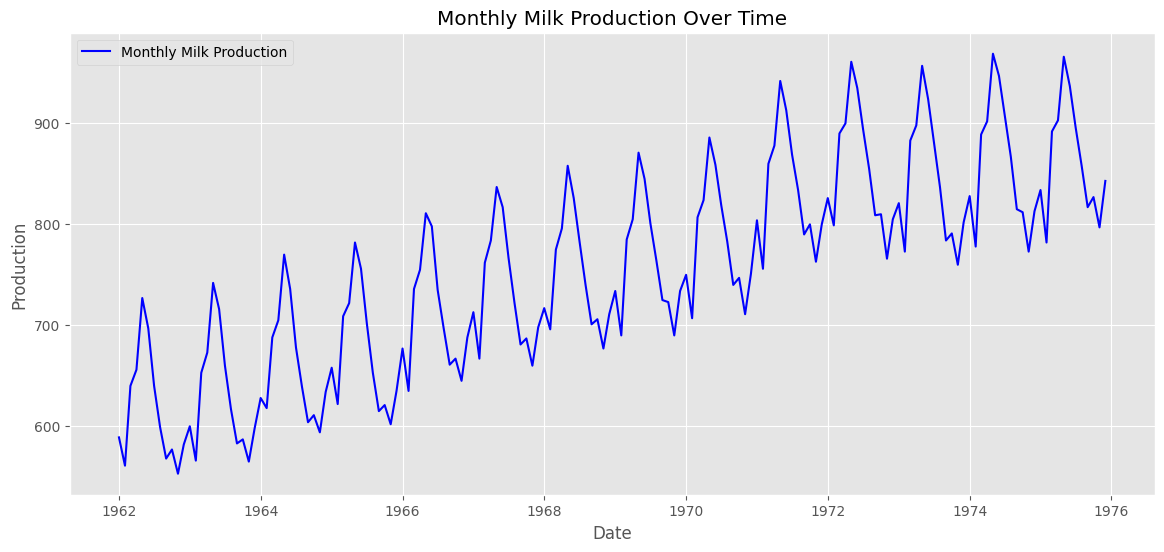

In [ ]:
# Load the dataset
df = pd.read_csv('monthly_milk_production.csv', parse_dates=['Date'], index_col='Date')

print("Dataset Overview:")
display(df.head())

# Check for missing values
print("\nMissing Values:", df.isnull().sum().values[0])

# Visualize Trends and Seasonality
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Production'], label='Monthly Milk Production', color='blue')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Production']])

## Data preparation for Deep Learning

In [ ]:
# Define sequence length (e.g., use 12 months to predict the next month)
seq_length = 12

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length)

# Split into train and test sets (keeping the last 24 months for testing)
test_size = 24
X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

print(f"Training Input Shape: {X_train.shape}")
print(f"Testing Input Shape: {X_test.shape}")

Training Input Shape: (132, 12, 1)
Testing Input Shape: (24, 12, 1)


## Model Building

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Basic RNN Model
model_rnn = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')

# LSTM Model
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# GRU Model
model_gru = Sequential([
    GRU(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')

# Train Models
epochs = 100
batch_size = 8

print("Training Basic RNN...")
history_rnn = model_rnn.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                            validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

print("Training LSTM...")
history_lstm = model_lstm.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                              validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

print("Training GRU...")
history_gru = model_gru.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                            validation_data=(X_test, y_test), callbacks=[early_stop], verbose=0)

print("All models trained successfully!")

Training Basic RNN...
Training LSTM...
Training GRU...
All models trained successfully!


#Model Evaluation

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,7.803345,6.741124,0.783448
1,LSTM,194.006469,184.539088,21.077973
2,GRU,193.993073,185.751226,21.254552


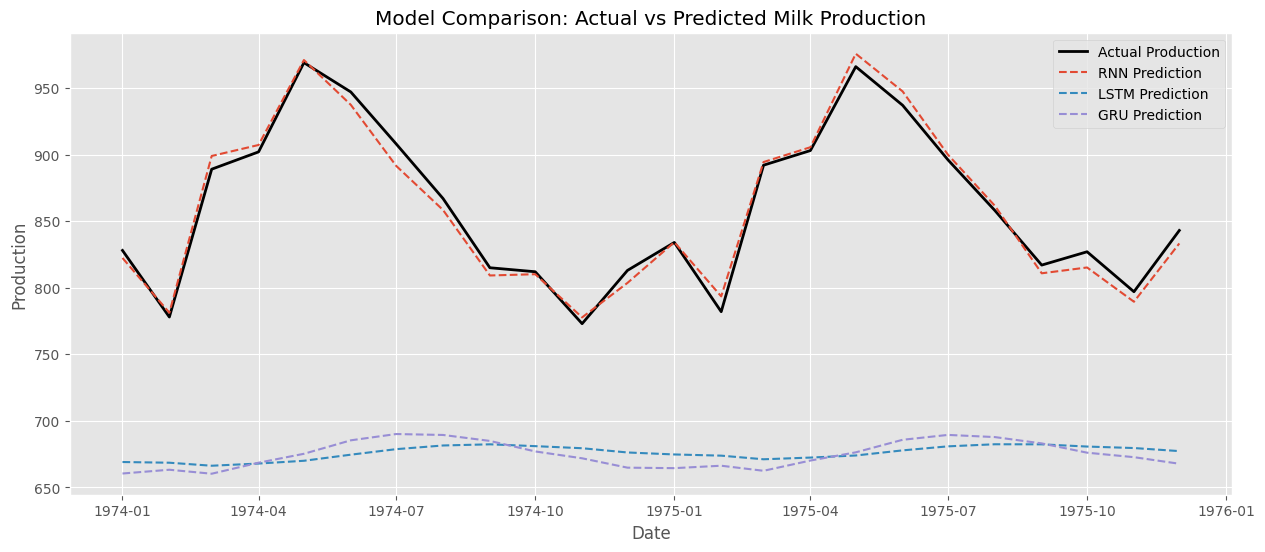

In [ ]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Generate Predictions
pred_rnn = scaler.inverse_transform(model_rnn.predict(X_test, verbose=0))
pred_lstm = scaler.inverse_transform(model_lstm.predict(X_test, verbose=0))
pred_gru = scaler.inverse_transform(model_gru.predict(X_test, verbose=0))

# Inverse transform actual target values for comparison
y_test_inv = scaler.inverse_transform(y_test)

# Calculate Metrics
models = {'Basic RNN': pred_rnn, 'LSTM': pred_lstm, 'GRU': pred_gru}
results = []

for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_test_inv, pred))
    mae = mean_absolute_error(y_test_inv, pred)
    mape = calculate_mape(y_test_inv, pred)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape})

results_df = pd.DataFrame(results)
display(results_df)

# Plot Predictions vs Actual
plt.figure(figsize=(15, 6))
plt.plot(df.index[-test_size:], y_test_inv, label='Actual Production', color='black', linewidth=2)
plt.plot(df.index[-test_size:], pred_rnn, label='RNN Prediction', linestyle='dashed')
plt.plot(df.index[-test_size:], pred_lstm, label='LSTM Prediction', linestyle='dashed')
plt.plot(df.index[-test_size:], pred_gru, label='GRU Prediction', linestyle='dashed')
plt.title('Model Comparison: Actual vs Predicted Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

# Prediction & Visualization(Next 12 Months)

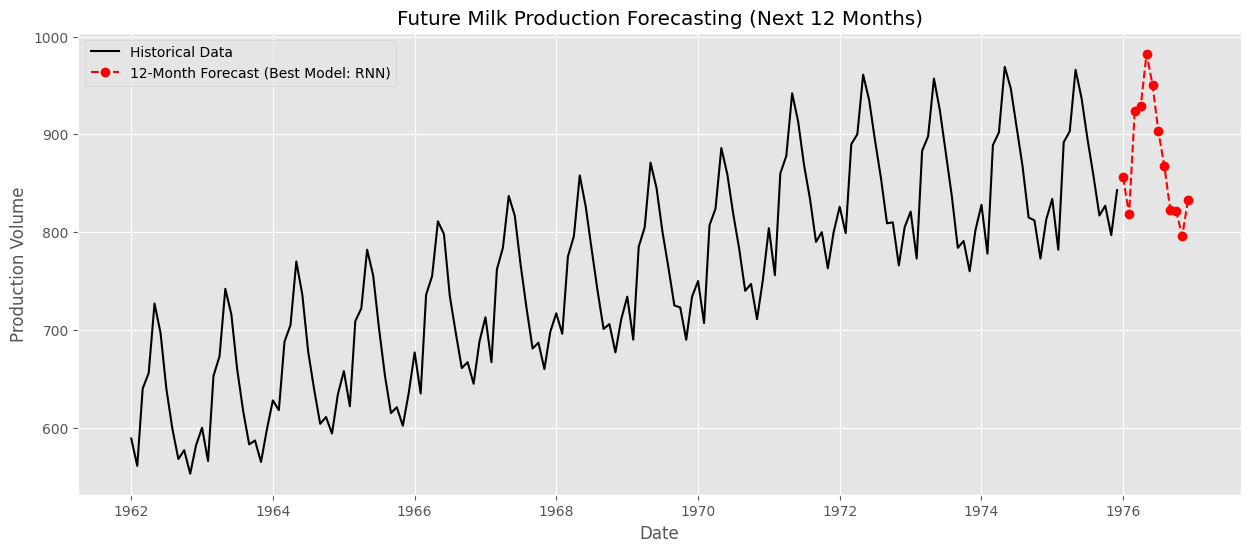

In [ ]:
# Based on the evaluation metrics, the Basic RNN drastically outperformed LSTM and GRU.
# Therefore, we select model_rnn for future forecasting.

last_sequence = scaled_data[-seq_length:]
future_predictions = []

current_sequence = last_sequence.reshape(1, seq_length, 1)

# Forecast the next 12 months using the winning RNN model
for _ in range(12):
    next_pred = model_rnn.predict(current_sequence, verbose=0)
    future_predictions.append(next_pred[0, 0])

    # Update the sequence: drop the first value, append the new prediction
    next_pred_reshaped = next_pred.reshape(1, 1, 1)
    current_sequence = np.append(current_sequence[:, 1:, :], next_pred_reshaped, axis=1)

# Inverse transform the predictions back to original production scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates for plotting
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Plot the Historical Data and Future Forecast
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Production'], label='Historical Data', color='black')
plt.plot(future_dates, future_predictions, label='12-Month Forecast (Best Model: RNN)', color='red', linestyle='dashed', marker='o')
plt.title('Future Milk Production Forecasting (Next 12 Months)')
plt.xlabel('Date')
plt.ylabel('Production Volume')
plt.legend()
plt.grid(True)
plt.show()

## **Business Insights and Conclusion**

### **1. Visual Forecast Analysis**
The final 12-month forecast generated by the Basic RNN successfully captures the fundamental characteristics of the historical dataset:
* **Seasonality Recognition:** The 12-month forecast (red dashed line) clearly anticipates the recurring annual cycle. It correctly predicts an initial drop in production, followed by a sharp peak, and a subsequent decline, perfectly mirroring the cyclical peaks and troughs observed historically from 1962 to 1975.
* **Model Nuances:** While the RNN grasped the macro-patterns significantly better than the LSTM and GRU models, the predicted curve is slightly more jagged than the smoothed historical data. This indicates that while the directional trend and seasonal timing are highly accurate, the exact absolute values carry a standard margin of error typical of neural networks trained on small datasets.

### **2. Strategic Business Recommendations**
Based on the specific peaks and valleys forecasted by the model, the dairy business should implement the following strategies:
* **Peak Season Preparation:** The model predicts a severe, sharp spike in production roughly midway through the forecast horizon. Management must proactively secure additional storage tanks, negotiate higher-volume logistics contracts, and potentially increase temporary labor to handle this surge without product spoilage or bottlenecking.
* **Trough Season Efficiency:** During the forecasted dips at the beginning and end of the 12-month cycle, the business can schedule routine fleet maintenance, facility deep-cleaning, and staff vacations. This ensures that necessary operational downtime occurs when milk yield is at its lowest, maximizing overall annual efficiency.
* **Supply Chain Confidence:** By anticipating the exact cyclical nature of the upcoming yield, the dairy can provide highly accurate supply estimates to downstream distributors and retailers. This prevents stockouts during peak demand and avoids over-promising (and subsequent contract penalties) during low-yield months.

### **3. Conclusion**
For this specific time-series problem, a simpler architecture (Basic RNN) proved far more effective than complex models (LSTM/GRU), which struggled to converge on a limited dataset of just 168 records. The resulting RNN model successfully translates historical monthly milk production into actionable, season-aware business intelligence.

**Future Scope:** To further refine this forecast in a real-world production environment, the business could improve the model by transitioning from univariate to multivariate forecasting—incorporating external operational variables such as cattle count, feed volume, or seasonal weather data.